In [2]:
import os
from dotenv import load_dotenv
import requests
import pandas as pd
import json
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

load_dotenv()

# Configuración de la API
API_KEY = os.getenv("API_KEY")
API_HOST = os.getenv("API_HOST")
BASE_URL = "https://meteostat.p.rapidapi.com/stations/daily"

# Parámetros de la consulta
params = {
    "station": os.getenv("STATION", "10637"),
    "start": os.getenv("START_DATE", "2015-03-01"),
    "end": os.getenv("END_DATE", "2025-01-01"),
    "tz": os.getenv("TIMEZONE", "America/El_Salvador")
}

# Headers requeridos por RapidAPI
headers = {
    "X-RapidAPI-Key": API_KEY,
    "X-RapidAPI-Host": "meteostat.p.rapidapi.com"
}

# Realizar la petición
try:
    response = requests.get(BASE_URL, headers=headers, params=params)
    response.raise_for_status()  # Lanza excepción si hay error HTTP

    # Obtener los datos
    data = response.json()

    print("✓ Datos obtenidos exitosamente")
    print(f"Status Code: {response.status_code}")

    # Convertir a DataFrame de pandas para análisis
    if 'data' in data:
        df = pd.DataFrame(data['data'])

        # Convertir la columna de fecha a datetime
        if 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'])

        print(f"\nTotal de registros: {len(df)}")
        print("\nPrimeras filas:")
        print(df.head())

    else:
        print("Respuesta completa:", json.dumps(data, indent=2))

except requests.exceptions.HTTPError as e:
    print(f"✗ Error HTTP: {e}")
    print(f"Respuesta: {response.text}")
except requests.exceptions.RequestException as e:
    print(f"✗ Error en la petición: {e}")
except json.JSONDecodeError:
    print(f"✗ Error al decodificar JSON. Respuesta: {response.text}")

✓ Datos obtenidos exitosamente
Status Code: 200

Total de registros: 3595

Primeras filas:
        date  tavg  tmin  tmax  prcp  snow  wdir  wspd  wpgt    pres  tsun
0 2015-03-01   6.4   2.3  10.3   1.5   0.0  None  20.5  55.4  1008.4    66
1 2015-03-02   6.7   1.8  10.2   0.4   0.0  None  25.2  78.8  1008.8   276
2 2015-03-03   5.5  -0.1  10.8   1.2   0.0  None  22.0  61.2  1020.9   402
3 2015-03-04   4.3   0.8   8.2   0.2   0.0  None  16.2  64.1  1027.2   318
4 2015-03-05   5.0   0.7   8.5   0.0   0.0  None  11.9  35.3  1037.3   234


In [3]:
print("\nColumnas disponibles:")
print(df.columns.tolist())

print("\nInformación del DataFrame:")
print(df.info())


Columnas disponibles:
['date', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt', 'pres', 'tsun']

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3595 entries, 0 to 3594
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    3595 non-null   datetime64[ns]
 1   tavg    3595 non-null   float64       
 2   tmin    3595 non-null   float64       
 3   tmax    3595 non-null   float64       
 4   prcp    3595 non-null   float64       
 5   snow    3595 non-null   float64       
 6   wdir    0 non-null      object        
 7   wspd    3595 non-null   float64       
 8   wpgt    3594 non-null   float64       
 9   pres    3595 non-null   float64       
 10  tsun    3595 non-null   int64         
dtypes: datetime64[ns](1), float64(8), int64(1), object(1)
memory usage: 309.1+ KB
None


In [4]:
# Limpieza y preparación de datos para ML

# Renombrar columnas al español
column_mapping = {
    'date': 'fecha',
    'tavg': 'temp_promedio',
    'tmin': 'temp_minima',
    'tmax': 'temp_maxima',
    'prcp': 'precipitacion',
    'snow': 'nieve',
    'wdir': 'direccion_viento',
    'wspd': 'velocidad_viento',
    'wpgt': 'rafaga_viento',
    'pres': 'presion_atmosferica',
    'tsun': 'horas_sol'
}

df = df.rename(columns=column_mapping)

print("Columnas renombradas:")
print(df.columns.tolist())

# Crear una copia para no modificar los datos originales
df_clean = df.copy()

# 1. Manejo de valores nulos
print("Valores nulos por columna:")
print(df_clean.isnull().sum())

# 2. Eliminar columnas con demasiados valores nulos (>50%)
threshold = len(df_clean) * 0.5
df_clean = df_clean.dropna(thresh=threshold, axis=1)

# 3. Rellenar valores nulos en columnas numéricas con la mediana
numeric_columns = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 4. Eliminar filas con valores nulos restantes
df_clean = df_clean.dropna()

# 5. Eliminar duplicados basados en la fecha
df_clean = df_clean.drop_duplicates(subset=['fecha'], keep='first')

# 6. Ordenar por fecha
df_clean = df_clean.sort_values('fecha').reset_index(drop=True)

# 7. Verificar outliers usando IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers)

print("\nOutliers detectados por columna:")
for col in numeric_columns:
    if col in df_clean.columns:
        n_outliers = detect_outliers_iqr(df_clean, col)
        print(f"{col}: {n_outliers} outliers")

# 8. Mostrar columnas disponibles después de la limpieza
print("\nColumnas disponibles después de limpieza:")
print(df_clean.columns.tolist())

# 9. Información del DataFrame limpio
print("\nInformación del DataFrame limpio:")
print(df_clean.info())

# 10. Resumen final
print(f"\nDatos originales: {len(df)} filas")
print(f"Datos limpios: {len(df_clean)} filas")
print(f"Columnas finales: {df_clean.shape[1]}")
print("\nPrimeras filas del dataset limpio:")
print(df_clean.head())

Columnas renombradas:
['fecha', 'temp_promedio', 'temp_minima', 'temp_maxima', 'precipitacion', 'nieve', 'direccion_viento', 'velocidad_viento', 'rafaga_viento', 'presion_atmosferica', 'horas_sol']
Valores nulos por columna:
fecha                     0
temp_promedio             0
temp_minima               0
temp_maxima               0
precipitacion             0
nieve                     0
direccion_viento       3595
velocidad_viento          0
rafaga_viento             1
presion_atmosferica       0
horas_sol                 0
dtype: int64

Outliers detectados por columna:
temp_promedio: 0 outliers
temp_minima: 0 outliers
temp_maxima: 0 outliers
precipitacion: 559 outliers
nieve: 42 outliers
velocidad_viento: 121 outliers
rafaga_viento: 84 outliers
presion_atmosferica: 81 outliers
horas_sol: 0 outliers

Columnas disponibles después de limpieza:
['fecha', 'temp_promedio', 'temp_minima', 'temp_maxima', 'precipitacion', 'nieve', 'velocidad_viento', 'rafaga_viento', 'presion_atmosferica', 

Varianza explicada por cada componente:
PC1: 36.67%
PC2: 24.99%
PC3: 12.07%
PC4: 10.81%
PC5: 7.17%
PC6: 5.57%
PC7: 2.18%
PC8: 0.49%
PC9: 0.05%

Varianza acumulada:
PC1: 36.67%
PC2: 61.65%
PC3: 73.72%
PC4: 84.54%
PC5: 91.71%
PC6: 97.28%
PC7: 99.46%
PC8: 99.95%
PC9: 100.00%


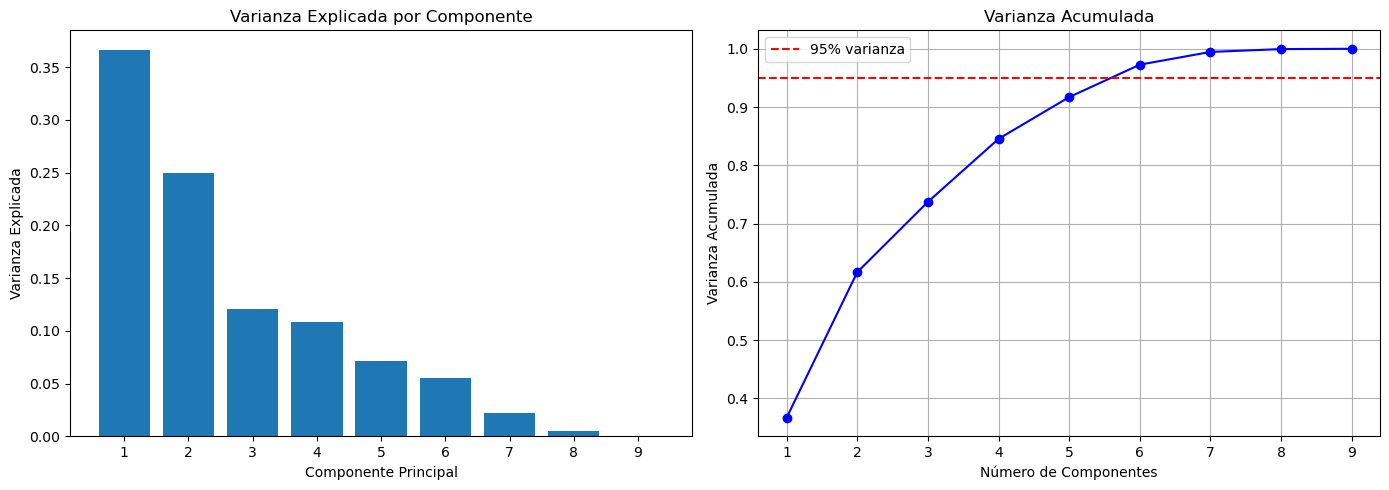


Número de componentes para explicar 95% de varianza: 6

Dimensiones originales: 9 features
Dimensiones reducidas: 6 componentes principales

Primeras filas del dataset reducido:
        PC1       PC2       PC3       PC4       PC5       PC6      fecha
0 -1.420139  2.023378 -0.570601 -0.236249 -0.660253  0.178077 2015-03-01
1 -1.133501  3.115456 -2.065763 -0.280094 -0.358521  0.747630 2015-03-02
2 -1.320362  1.408032 -1.831148 -0.372208  0.590900  0.717964 2015-03-03
3 -1.597850  0.676783 -1.762052 -0.446412  0.837042  0.252343 2015-03-04
4 -1.805146 -1.359024 -0.920279 -0.503326  1.191468 -0.540800 2015-03-05


In [5]:
# Preparar datos para PCA (excluir la columna de fecha)
df_pca = df_clean.select_dtypes(include=[np.number]).copy()

# 1. Estandarizar los datos (importante para PCA)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_pca)

# 2. Aplicar PCA
pca = PCA()
pca_features = pca.fit_transform(df_scaled)

# 3. Analizar la varianza explicada
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

print("Varianza explicada por cada componente:")
for i, var in enumerate(varianza_explicada, 1):
    print(f"PC{i}: {var*100:.2f}%")

print(f"\nVarianza acumulada:")
for i, var in enumerate(varianza_acumulada, 1):
    print(f"PC{i}: {var*100:.2f}%")

# 4. Visualizar la varianza explicada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de varianza por componente
ax1.bar(range(1, len(varianza_explicada) + 1), varianza_explicada)
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Varianza Explicada')
ax1.set_title('Varianza Explicada por Componente')
ax1.set_xticks(range(1, len(varianza_explicada) + 1))

# Gráfico de varianza acumulada
ax2.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, 'bo-')
ax2.axhline(y=0.95, color='r', linestyle='--', label='95% varianza')
ax2.set_xlabel('Número de Componentes')
ax2.set_ylabel('Varianza Acumulada')
ax2.set_title('Varianza Acumulada')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# 5. Determinar número óptimo de componentes (95% varianza)
n_components_95 = np.argmax(varianza_acumulada >= 0.95) + 1
print(f"\nNúmero de componentes para explicar 95% de varianza: {n_components_95}")

# 6. Crear DataFrame con componentes principales reducidos
pca_reduced = PCA(n_components=n_components_95)
df_pca_reduced = pca_reduced.fit_transform(df_scaled)

# Crear DataFrame con los componentes principales
columnas_pca = [f'PC{i+1}' for i in range(n_components_95)]
df_final = pd.DataFrame(df_pca_reduced, columns=columnas_pca)
df_final['fecha'] = df_clean['fecha'].values

print(f"\nDimensiones originales: {df_pca.shape[1]} features")
print(f"Dimensiones reducidas: {n_components_95} componentes principales")
print(f"\nPrimeras filas del dataset reducido:")
print(df_final.head())

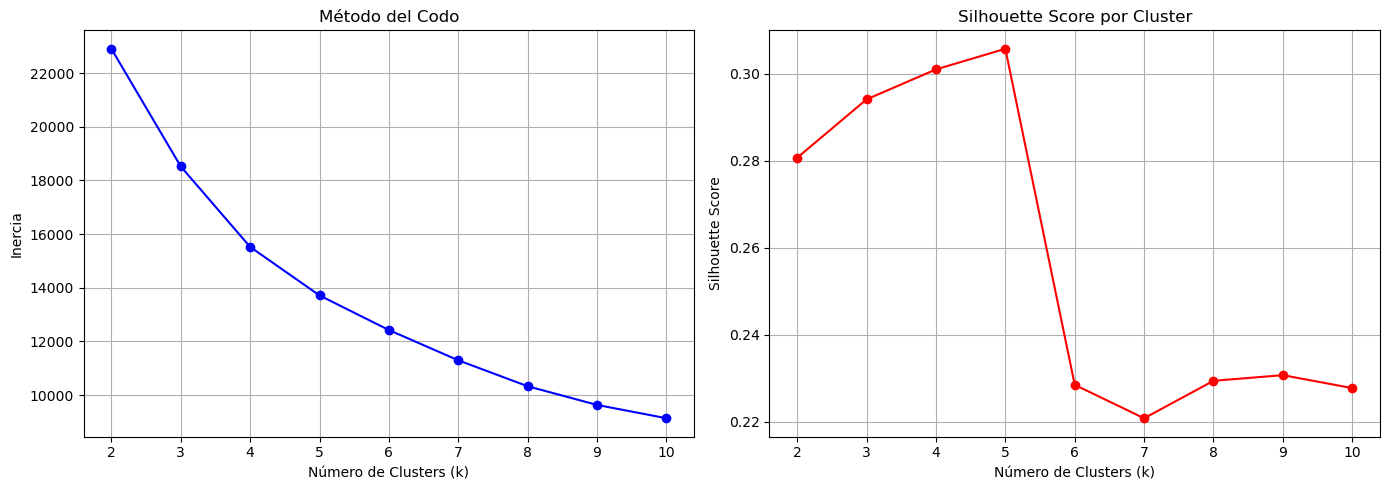

Número óptimo de clusters sugerido: 5

Métricas de calidad del clustering:
Silhouette Score: 0.306 (más cercano a 1 es mejor)
Davies-Bouldin Index: 1.087 (más cercano a 0 es mejor)
Calinski-Harabasz Score: 1162.024 (mayor es mejor)

Distribución de observaciones por cluster:
cluster
0    1389
1      25
2     704
3    1222
4     255
Name: count, dtype: int64


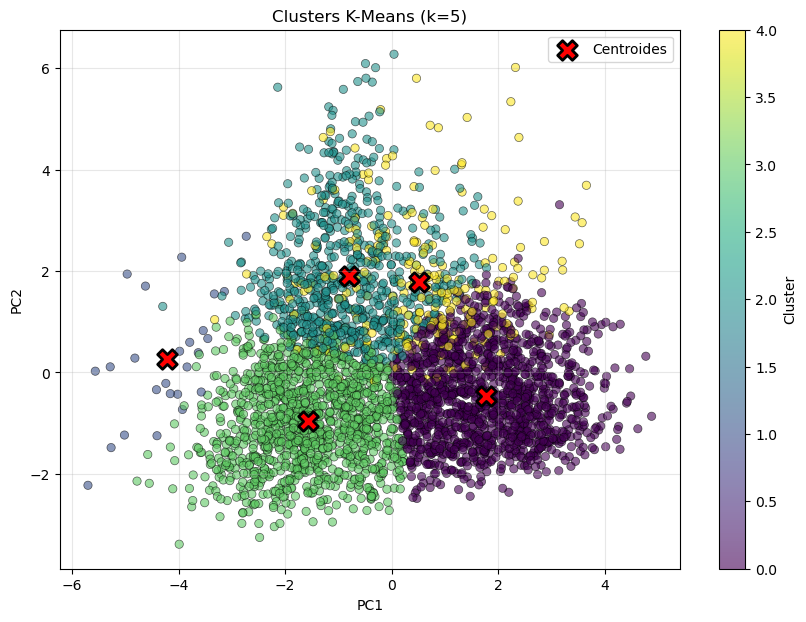


Características promedio por cluster (datos originales):

--- Cluster 0 ---
Número de días: 1389
temp_promedio            18.95
temp_minima              12.51
temp_maxima              25.27
precipitacion             0.49
nieve                     0.00
velocidad_viento         10.76
rafaga_viento            37.40
presion_atmosferica    1018.22
horas_sol               529.14
cluster                   0.00
dtype: float64

--- Cluster 1 ---
Número de días: 25
temp_promedio            -0.41
temp_minima              -3.04
temp_maxima               1.92
precipitacion             1.22
nieve                    30.40
velocidad_viento         13.39
rafaga_viento            38.28
presion_atmosferica    1015.53
horas_sol                60.48
cluster                   1.00
dtype: float64

--- Cluster 2 ---
Número de días: 704
temp_promedio             9.06
temp_minima               5.45
temp_maxima              12.40
precipitacion             2.05
nieve                     0.09
velocidad_viento    

In [6]:
# 1. Determinar el número óptimo de clusters usando el método del codo
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca_reduced)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_pca_reduced, kmeans.labels_))

# Visualizar métricas para elegir k óptimo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Método del codo
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del Codo')
ax1.grid(True)

# Silhouette Score
ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score por Cluster')
ax2.grid(True)

plt.tight_layout()
plt.show()

# 2. Aplicar K-Means con el número óptimo de clusters
k_optimo = K_range[np.argmax(silhouette_scores)]
print(f"Número óptimo de clusters sugerido: {k_optimo}")

kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(df_pca_reduced)

# 3. Agregar etiquetas de cluster al DataFrame
df_final['cluster'] = clusters

# 4. Evaluar calidad de clustering
silhouette = silhouette_score(df_pca_reduced, clusters)
davies_bouldin = davies_bouldin_score(df_pca_reduced, clusters)
calinski_harabasz = calinski_harabasz_score(df_pca_reduced, clusters)

print("\nMétricas de calidad del clustering:")
print(f"Silhouette Score: {silhouette:.3f} (más cercano a 1 es mejor)")
print(f"Davies-Bouldin Index: {davies_bouldin:.3f} (más cercano a 0 es mejor)")
print(f"Calinski-Harabasz Score: {calinski_harabasz:.3f} (mayor es mejor)")

# 5. Distribución de clusters
print("\nDistribución de observaciones por cluster:")
print(df_final['cluster'].value_counts().sort_index())

# 6. Visualizar clusters en 2D (primeros 2 componentes principales)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_final['PC1'], df_final['PC2'],
                     c=df_final['cluster'], cmap='viridis',
                     alpha=0.6, edgecolors='black', linewidth=0.5)
plt.scatter(kmeans_final.cluster_centers_[:, 0],
           kmeans_final.cluster_centers_[:, 1],
           c='red', marker='X', s=200, edgecolors='black',
           linewidth=2, label='Centroides')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Clusters K-Means (k={k_optimo})')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Características de cada cluster
print("\nCaracterísticas promedio por cluster (datos originales):")
df_clusters = df_clean.copy()
df_clusters['cluster'] = clusters

for cluster_id in range(k_optimo):
    print(f"\n--- Cluster {cluster_id} ---")
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    print(f"Número de días: {len(cluster_data)}")
    print(cluster_data.select_dtypes(include=[np.number]).mean().round(2))

print("\nPrimeras filas con clusters asignados:")
print(df_final.head(10))

Transacciones creadas:
Total de transacciones: 3595
Items únicos: 18

Items disponibles:
['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'invierno', 'lluvia_fuerte', 'lluvia_ligera', 'sin_lluvia', 'temp_alta', 'temp_baja', 'temp_media', 'transicion_lluviosa', 'transicion_seca', 'verano', 'viento_calmo', 'viento_fuerte', 'viento_moderado']

Itemsets frecuentes encontrados: 82

Top 10 itemsets más frecuentes:
     support                 itemsets
7   0.629764              (temp_baja)
6   0.561335             (sin_lluvia)
14  0.486231        (viento_moderado)
12  0.407789           (viento_calmo)
0   0.386370              (cluster_0)
8   0.340195             (temp_media)
2   0.339917              (cluster_3)
25  0.339917   (cluster_3, temp_baja)
36  0.325730  (sin_lluvia, temp_baja)
5   0.325174          (lluvia_ligera)

Reglas de asociación generadas: 248

Reglas significativas (lift>1.2, conf>0.6, sup>0.05): 71

Top 20 reglas con mayor lift:
                           

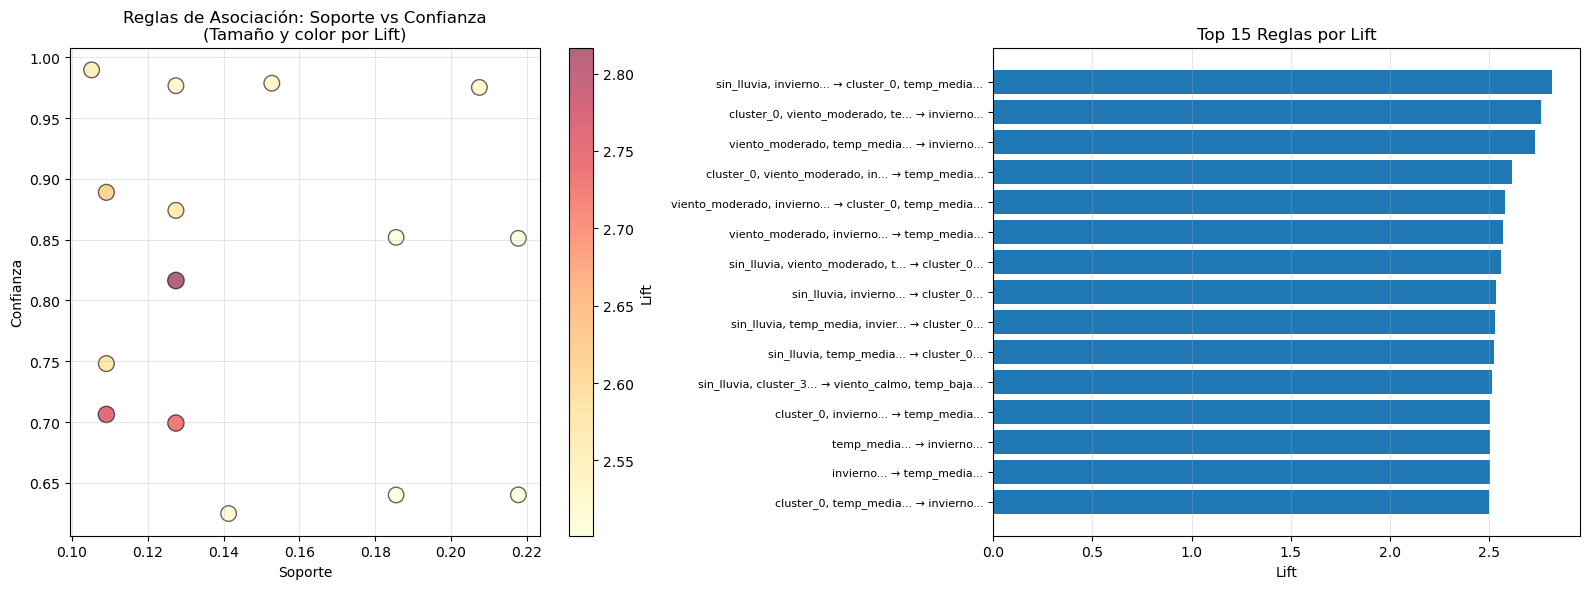


=== RESUMEN DE INSIGHTS ===
Total de reglas significativas: 71

Lift promedio: 1.98
Confianza promedio: 0.79
Soporte promedio: 0.16

Interpretación de métricas:
- Soporte: % de transacciones que contienen el itemset
- Confianza: Probabilidad de que ocurra el consecuente dado el antecedente
- Lift > 1: Indica asociación positiva (items relacionados)
- Lift = 1: Independencia (no hay relación)
- Lift < 1: Asociación negativa (items mutuamente exclusivos)


In [7]:
# 1. Preparar datos para reglas de asociación (discretizar variables continuas)
df_asociacion = df_clean.copy()
df_asociacion['cluster'] = clusters

# Discretizar variables numéricas en categorías
def discretizar_temp(x):
    if x < 15: return 'temp_baja'
    elif x < 25: return 'temp_media'
    else: return 'temp_alta'

def discretizar_precipitacion(x):
    if x == 0: return 'sin_lluvia'
    elif x < 5: return 'lluvia_ligera'
    else: return 'lluvia_fuerte'

def discretizar_viento(x):
    if pd.isna(x): return 'viento_na'
    elif x < 10: return 'viento_calmo'
    elif x < 20: return 'viento_moderado'
    else: return 'viento_fuerte'

# Aplicar discretización
df_asociacion['cat_temp'] = df_asociacion['temp_promedio'].apply(discretizar_temp)
df_asociacion['cat_precipitacion'] = df_asociacion['precipitacion'].apply(discretizar_precipitacion)
df_asociacion['cat_viento'] = df_asociacion['velocidad_viento'].apply(discretizar_viento)
df_asociacion['cat_cluster'] = df_asociacion['cluster'].apply(lambda x: f'cluster_{x}')

# Agregar estación del año
df_asociacion['mes'] = pd.to_datetime(df_asociacion['fecha']).dt.month
def obtener_estacion(mes):
    if mes in [12, 1, 2]: return 'verano'  # El Salvador
    elif mes in [3, 4, 5]: return 'transicion_seca'
    elif mes in [6, 7, 8]: return 'invierno'
    else: return 'transicion_lluviosa'

df_asociacion['estacion'] = df_asociacion['mes'].apply(obtener_estacion)

# 2. Crear transacciones (cada fila es una transacción con items)
transacciones = []
for _, row in df_asociacion.iterrows():
    transaccion = [
        row['cat_temp'],
        row['cat_precipitacion'],
        row['cat_viento'],
        row['cat_cluster'],
        row['estacion']
    ]
    transacciones.append(transaccion)

# 3. Codificar transacciones
te = TransactionEncoder()
te_array = te.fit(transacciones).transform(transacciones)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print("Transacciones creadas:")
print(f"Total de transacciones: {len(transacciones)}")
print(f"Items únicos: {len(te.columns_)}")
print("\nItems disponibles:")
print(list(te.columns_))

# 4. Encontrar itemsets frecuentes con Apriori
frequent_itemsets = apriori(df_encoded, min_support=0.1, use_colnames=True)
print(f"\nItemsets frecuentes encontrados: {len(frequent_itemsets)}")
print("\nTop 10 itemsets más frecuentes:")
print(frequent_itemsets.sort_values('support', ascending=False).head(10))

# 5. Generar reglas de asociación
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False)

print(f"\nReglas de asociación generadas: {len(rules)}")

# 6. Filtrar y mostrar las mejores reglas
reglas_significativas = rules[
    (rules['lift'] > 1.2) &
    (rules['confidence'] > 0.6) &
    (rules['support'] > 0.05)
].copy()

print(f"\nReglas significativas (lift>1.2, conf>0.6, sup>0.05): {len(reglas_significativas)}")

# Formatear para mejor visualización
reglas_significativas['antecedents'] = reglas_significativas['antecedents'].apply(lambda x: ', '.join(list(x)))
reglas_significativas['consequents'] = reglas_significativas['consequents'].apply(lambda x: ', '.join(list(x)))

# Seleccionar columnas relevantes
columnas_mostrar = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print("\nTop 20 reglas con mayor lift:")
print(reglas_significativas[columnas_mostrar].head(20).to_string(index=False))

# 7. Análisis de reglas por cluster
print("\n=== Reglas específicas por cluster ===")
for cluster_id in range(k_optimo):
    cluster_name = f'cluster_{cluster_id}'
    reglas_cluster = reglas_significativas[
        reglas_significativas['consequents'].str.contains(cluster_name)
    ]
    if len(reglas_cluster) > 0:
        print(f"\n--- Reglas que predicen {cluster_name} ---")
        print(reglas_cluster[columnas_mostrar].head(5).to_string(index=False))

# 8. Visualizar las mejores reglas
top_rules = reglas_significativas.head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico Soporte vs Confianza coloreado por Lift
scatter = ax1.scatter(top_rules['support'], top_rules['confidence'],
                     s=top_rules['lift']*50, c=top_rules['lift'],
                     cmap='YlOrRd', alpha=0.6, edgecolors='black')
ax1.set_xlabel('Soporte')
ax1.set_ylabel('Confianza')
ax1.set_title('Reglas de Asociación: Soporte vs Confianza\n(Tamaño y color por Lift)')
plt.colorbar(scatter, ax=ax1, label='Lift')
ax1.grid(True, alpha=0.3)

# Gráfico de barras con las mejores reglas por Lift
reglas_labels = [f"{ant[:30]}... → {cons[:30]}..."
                for ant, cons in zip(top_rules['antecedents'], top_rules['consequents'])]
ax2.barh(range(len(top_rules)), top_rules['lift'].values)
ax2.set_yticks(range(len(top_rules)))
ax2.set_yticklabels(reglas_labels, fontsize=8)
ax2.set_xlabel('Lift')
ax2.set_title('Top 15 Reglas por Lift')
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# 9. Resumen de insights
print("\n=== RESUMEN DE INSIGHTS ===")
print(f"Total de reglas significativas: {len(reglas_significativas)}")
print(f"\nLift promedio: {reglas_significativas['lift'].mean():.2f}")
print(f"Confianza promedio: {reglas_significativas['confidence'].mean():.2f}")
print(f"Soporte promedio: {reglas_significativas['support'].mean():.2f}")

print("\nInterpretación de métricas:")
print("- Soporte: % de transacciones que contienen el itemset")
print("- Confianza: Probabilidad de que ocurra el consecuente dado el antecedente")
print("- Lift > 1: Indica asociación positiva (items relacionados)")
print("- Lift = 1: Independencia (no hay relación)")
print("- Lift < 1: Asociación negativa (items mutuamente exclusivos)")